# 深度域礁核相控半径调试 QC

用途：地质人员从地质软件取得礁核 `x/y/depth` 后，在这里反复调试横向半径 `radius_xy_m`、纵向半径 `radius_z_m` 和目标低阻抗 `target_ai`。

运行节奏：

- **只跑一次**：环境/路径配置、大体数据加载。
- **可反复跑**：礁核参数、局部相控计算、剖面 QC、正演 QC、保存 trial。

注意：半径单位均为米；`target_ai` 是绝对 AI 值，不是百分比；本 notebook 只做 QC 和调参记录，不生成正式生产 NPZ。正式多点产出请使用 `scripts/lfm_facies_control_depth.py`。


In [1]:
# Cell 1 - 只跑一次：环境与路径配置
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    # 如果 notebook 当前目录是 notebooks/，则回到 repo root
    REPO_ROOT = REPO_ROOT.parent

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

COMMON_CONFIG = REPO_ROOT / "experiments/common_depth.yaml"
TRAIN_CONFIG = REPO_ROOT / "experiments/ginn_depth/train.yaml"

# 可按需覆盖；None 表示从 common_depth.yaml / train.yaml 自动读取
SOURCE_AI_LFM_FILE = None
VP_LFM_FILE = None
WAVELET_FILE = None
DYNAMIC_GAIN_FILE = None
SEISMIC_FILE = None

# 正演建议使用 cpu；单道 QC 不需要 GPU
FORWARD_DEVICE = "cpu"

print("REPO_ROOT =", REPO_ROOT)
print("COMMON_CONFIG =", COMMON_CONFIG)
print("TRAIN_CONFIG =", TRAIN_CONFIG)

REPO_ROOT = c:\Users\WangQinZhuo\Program\libra_workflow_standardize
COMMON_CONFIG = c:\Users\WangQinZhuo\Program\libra_workflow_standardize\experiments\common_depth.yaml
TRAIN_CONFIG = c:\Users\WangQinZhuo\Program\libra_workflow_standardize\experiments\ginn_depth\train.yaml


In [2]:
# Cell 2 - 只跑一次：导入后端计算工具、Notebook 展示 helper，并加载大体数据
import json
from datetime import datetime, timezone
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cup.seismic.facies_control_depth import (
    apply_single_control_to_window,
    forward_qc_at_control_trace,
    load_qc_context,
    make_control_point,
)


# ===== 初始化与摘要 helper =====
def read_notebook_run_summary(context) -> dict[str, Any]:
    return {
        "repo_root": str(context.repo_root),
        "ai_shape": tuple(int(v) for v in context.ai_lfm.shape),
        "gain_mode": context.gain_mode,
        "seis_rms": float(context.seis_rms),
        "seismic_file": str(context.seismic_file),
        "common_config_path": str(context.common_config_path),
        "train_config_path": str(context.train_config_path),
    }


def pretty_json(value: Any) -> str:
    return json.dumps(value, ensure_ascii=False, indent=2)


# ===== 地质体剖面绘图 helper =====
def _axis_edges(values: np.ndarray) -> tuple[float, float]:
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0:
        return 0.0, 1.0
    if values.size == 1:
        return float(values[0] - 0.5), float(values[0] + 0.5)
    diffs = np.diff(values)
    return float(values[0] - 0.5 * diffs[0]), float(values[-1] + 0.5 * diffs[-1])


def _plot_section_row(
    axes: np.ndarray,
    before: np.ndarray,
    after: np.ndarray,
    delta: np.ndarray,
    weight: np.ndarray,
    *,
    title_prefix: str,
    x_values: np.ndarray,
    center_x: float,
    x_label: str,
    depth_values: np.ndarray,
    control_depth: float,
    zone_top: np.ndarray,
    zone_bottom: np.ndarray,
) -> None:
    vmin = float(np.nanpercentile(before, 2.0))
    vmax = float(np.nanpercentile(before, 98.0))
    delta_clip = max(float(np.nanpercentile(np.abs(delta), 99.0)), 1.0)
    panels = [
        (before, "before AI", "viridis", vmin, vmax),
        (after, "after AI", "viridis", vmin, vmax),
        (delta, "after - before", "coolwarm", -delta_clip, delta_clip),
        (weight, "control weight", "magma", 0.0, max(float(np.nanmax(weight)), 1e-6)),
    ]
    x_values = np.asarray(x_values, dtype=np.float64)
    extent = [*_axis_edges(x_values), float(depth_values[-1]), float(depth_values[0])]
    for ax, (values, label, cmap, lo, hi) in zip(axes, panels):
        im = ax.imshow(values.T, aspect="auto", origin="upper", cmap=cmap, vmin=lo, vmax=hi, extent=extent)
        ax.axvline(center_x, color="white", lw=0.8, ls="--")
        ax.axhline(control_depth, color="white", lw=0.8, ls=":")
        ax.plot(x_values, zone_top, color="white", lw=1.1, ls="-", alpha=0.9)
        ax.plot(x_values, zone_bottom, color="white", lw=1.1, ls="-", alpha=0.9)
        ax.set_ylim(float(depth_values[-1]), float(depth_values[0]))
        ax.set_title(f"{title_prefix}: {label}")
        ax.set_xlabel(x_label)
        ax.set_ylabel("depth (m)")
        plt.colorbar(im, ax=ax, shrink=0.8)


def plot_control_sections(result) -> None:
    li = result.il_idx - int(result.il_slice.start)
    lj = result.xl_idx - int(result.xl_slice.start)
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
    _plot_section_row(
        axes[0],
        result.source_ai_window[:, lj, :],
        result.controlled_ai_window[:, lj, :],
        result.diff_window[:, lj, :],
        result.weight_window[:, lj, :],
        title_prefix="Inline direction",
        x_values=result.ilines_window,
        center_x=float(result.ilines_window[li]),
        x_label="inline",
        depth_values=result.depth_window,
        control_depth=result.point.depth_m,
        zone_top=result.zone_top_window[:, lj],
        zone_bottom=result.zone_bottom_window[:, lj],
    )
    _plot_section_row(
        axes[1],
        result.source_ai_window[li, :, :],
        result.controlled_ai_window[li, :, :],
        result.diff_window[li, :, :],
        result.weight_window[li, :, :],
        title_prefix="Xline direction",
        x_values=result.xlines_window,
        center_x=float(result.xlines_window[lj]),
        x_label="xline",
        depth_values=result.depth_window,
        control_depth=result.point.depth_m,
        zone_top=result.zone_top_window[li, :],
        zone_bottom=result.zone_bottom_window[li, :],
    )
    fig.suptitle(
        f"{result.point.name} | inline={result.inline:.1f}, xline={result.xline:.1f}, "
        f"Rxy={result.point.radius_xy_m:.0f} m, Rz={result.point.radius_z_m:.0f} m"
    )
    plt.show()
    if result.warning:
        print(f"WARNING: {result.warning}")
    print(result.qc_df.drop(columns=["horizon_values"], errors="ignore").to_string(index=False))


# ===== 单道正演绘图 helper =====
def _true_runs(mask: np.ndarray) -> list[tuple[int, int]]:
    mask = np.asarray(mask, dtype=bool).reshape(-1)
    padded = np.r_[False, mask, False]
    changes = np.flatnonzero(padded[1:] != padded[:-1])
    return [(int(changes[i]), int(changes[i + 1])) for i in range(0, len(changes), 2)]


def _shade_influence_depths(ax: Any, depth: np.ndarray, influence_mask: np.ndarray | None) -> None:
    if influence_mask is None:
        return
    depth = np.asarray(depth, dtype=np.float64)
    mask = np.asarray(influence_mask, dtype=bool)
    if depth.size == 0 or mask.size != depth.size or not np.any(mask):
        return
    for start, stop in _true_runs(mask):
        top = float(depth[start])
        bottom = float(depth[stop - 1])
        ax.axhspan(top, bottom, color="gold", alpha=0.16, lw=0, zorder=0)


def plot_forward_qc(metrics: pd.DataFrame, waveforms: dict[str, np.ndarray], *, gain_mode: str) -> None:
    depth = waveforms["depth"]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    axes[0].plot(waveforms["real"], depth, color="black", lw=1.2, label="real")
    axes[0].plot(waveforms["synthetic_before"], depth, color="tab:blue", lw=1.0, label="before synthetic")
    axes[0].plot(waveforms["synthetic_after"], depth, color="tab:red", lw=1.0, label="after synthetic")
    axes[0].invert_yaxis()
    axes[0].set_title(f"Training-normalized amplitude ({gain_mode})")
    axes[0].set_xlabel("amplitude")
    axes[0].set_ylabel("depth (m)")
    axes[0].legend()

    axes[1].plot(waveforms["real"], depth, color="black", lw=1.2, label="real")
    axes[1].plot(waveforms["synthetic_before_rms_match"], depth, color="tab:blue", lw=1.0, label="before RMS match")
    axes[1].plot(waveforms["synthetic_after_rms_match"], depth, color="tab:red", lw=1.0, label="after RMS match")
    axes[1].invert_yaxis()
    axes[1].set_title("Local RMS matched")
    axes[1].set_xlabel("amplitude")
    axes[1].set_ylabel("depth (m)")
    axes[1].legend()
    for ax in axes:
        _shade_influence_depths(ax, depth, waveforms.get("influence_mask"))
    plt.show()
    print(metrics.to_string(index=False))


# ===== trial 记录 helper =====
def trial_csv_path(repo_root: Path, control_name: str) -> Path:
    safe = "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in str(control_name))
    return repo_root / "scripts" / "output" / "lfm_facies_control_depth_qc_trials" / f"{safe}.csv"


def append_trial_record(output_csv: str | Path, result, metrics: pd.DataFrame) -> pd.DataFrame:
    output_csv = Path(output_csv)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    metric_row = {
        f"{row['window']}_{row['metric_set']}_{key}": value
        for _, row in metrics.iterrows()
        for key, value in row.items()
        if key not in {"metric_set", "window"}
    }
    qc = result.qc_df.iloc[0].drop(labels=["horizon_values"], errors="ignore").to_dict()
    row = {
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        **qc,
        **metric_row,
    }
    if output_csv.exists():
        df = pd.read_csv(output_csv)
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    else:
        df = pd.DataFrame([row])
    df.to_csv(output_csv, index=False, encoding="utf-8-sig")
    return df


ctx = load_qc_context(
    common_config_path=COMMON_CONFIG,
    train_config_path=TRAIN_CONFIG,
    source_ai_lfm_file=SOURCE_AI_LFM_FILE,
    vp_lfm_file=VP_LFM_FILE,
    wavelet_file=WAVELET_FILE,
    dynamic_gain_file=DYNAMIC_GAIN_FILE,
    seismic_file=SEISMIC_FILE,
    device=FORWARD_DEVICE,
)

print(pretty_json(read_notebook_run_summary(ctx)))

100%|██████████| 481401/481401 [00:01<00:00, 326604.34it/s]


{
  "repo_root": "C:\\Users\\WangQinZhuo\\Program\\libra_workflow_standardize",
  "ai_shape": [
    601,
    801,
    551
  ],
  "gain_mode": "dynamic_gain_model",
  "seis_rms": 7334.7939453126,
  "seismic_file": "C:\\Users\\WangQinZhuo\\Program\\libra_workflow_standardize\\data\\raw\\mero_84_coord_extend",
  "common_config_path": "c:\\Users\\WangQinZhuo\\Program\\libra_workflow_standardize\\experiments\\common_depth.yaml",
  "train_config_path": "c:\\Users\\WangQinZhuo\\Program\\libra_workflow_standardize\\experiments\\ginn_depth\\train.yaml"
}


## Cell 3 参数提醒

第一次运行前请先填写 `x/y/depth_m/target_ai`。模板不会提供默认坐标，避免把示例点误当成生产点。


In [3]:
# Cell 3 - 可反复跑：礁核参数，只改这里
# 必须先从地质软件填入礁核中心坐标和深度；半径单位是米，target_ai 是绝对 AI。
# 默认 None 会主动报错，避免误用模板占位坐标。
control_name = "reef_core_001"
x = 786093.0
y = 7274335.0
depth_m = 6032.0
target_ai = 8000.0
radius_xy_m = 500.0
radius_z_m = 60.0
strength = 1.0

# 正演 influence_only 指标使用的权重阈值；raised-cosine 下 0.01 基本覆盖到透镜体边界。
influence_weight_threshold = 0.01

# 剖面显示范围：横向半宽约为 section_scale * 2 * radius_xy_m；纵向半高为 section_scale * radius_z_m
section_scale = 1.2

required_values = {
    "x": x,
    "y": y,
    "depth_m": depth_m,
    "target_ai": target_ai,
    "radius_xy_m": radius_xy_m,
    "radius_z_m": radius_z_m,
    "strength": strength,
}
missing = [name for name, value in required_values.items() if value is None]
if missing:
    raise ValueError("请先在 Cell 3 填写这些参数：" + ", ".join(missing))

point = make_control_point(
    name=control_name,
    x=x,
    y=y,
    depth_m=depth_m,
    radius_xy_m=radius_xy_m,
    radius_z_m=radius_z_m,
    target_ai=target_ai,
    strength=strength,
)
point

FaciesControlPoint(name='reef_core_001', x=786093.0, y=7274335.0, depth_m=6032.0, radius_xy_m=500.0, radius_z_m=60.0, target_ai=8000.0, strength=1.0)

In [4]:
# Cell 4 - 可反复跑：局部相控计算
# 只截取局部窗口，不处理整块体；横向窗口按真实 XY 米制距离选取。
result = apply_single_control_to_window(ctx, point, section_scale=section_scale)

print(f"inline={result.inline:.2f}, xline={result.xline:.2f}")
print(f"nearest indices: il={result.il_idx}, xl={result.xl_idx}")
if result.warning:
    print("WARNING:", result.warning)
display(result.qc_df.drop(columns=["horizon_values"], errors="ignore"))
print("horizon values at control point:")
print(pretty_json(result.qc_df.iloc[0]["horizon_values"]))

inline=1948.43, xline=5661.64
nearest indices: il=447, xl=466


,order,name,x,y,depth_m,inline,xline,zone_top,zone_bottom,radius_xy_m,...,strength,affected_traces,affected_samples,overlap_samples,max_weight,mean_weight,mean_ai_before,mean_ai_after,mean_ai_delta,max_abs_ai_delta
0,0,reef_core_001,786093.0,7274335.0,6032.0,1948.429699,5661.640181,horizon_0,horizon_1,500.0,...,1.0,1262,26975,0,0.995417,0.163581,12315.434441,11517.403876,-798.030565,4540.429466


horizon values at control point:
{
  "horizon_0": 5878.83176247592,
  "horizon_1": 6109.656018413877,
  "horizon_2": 6300.8207412144275
}


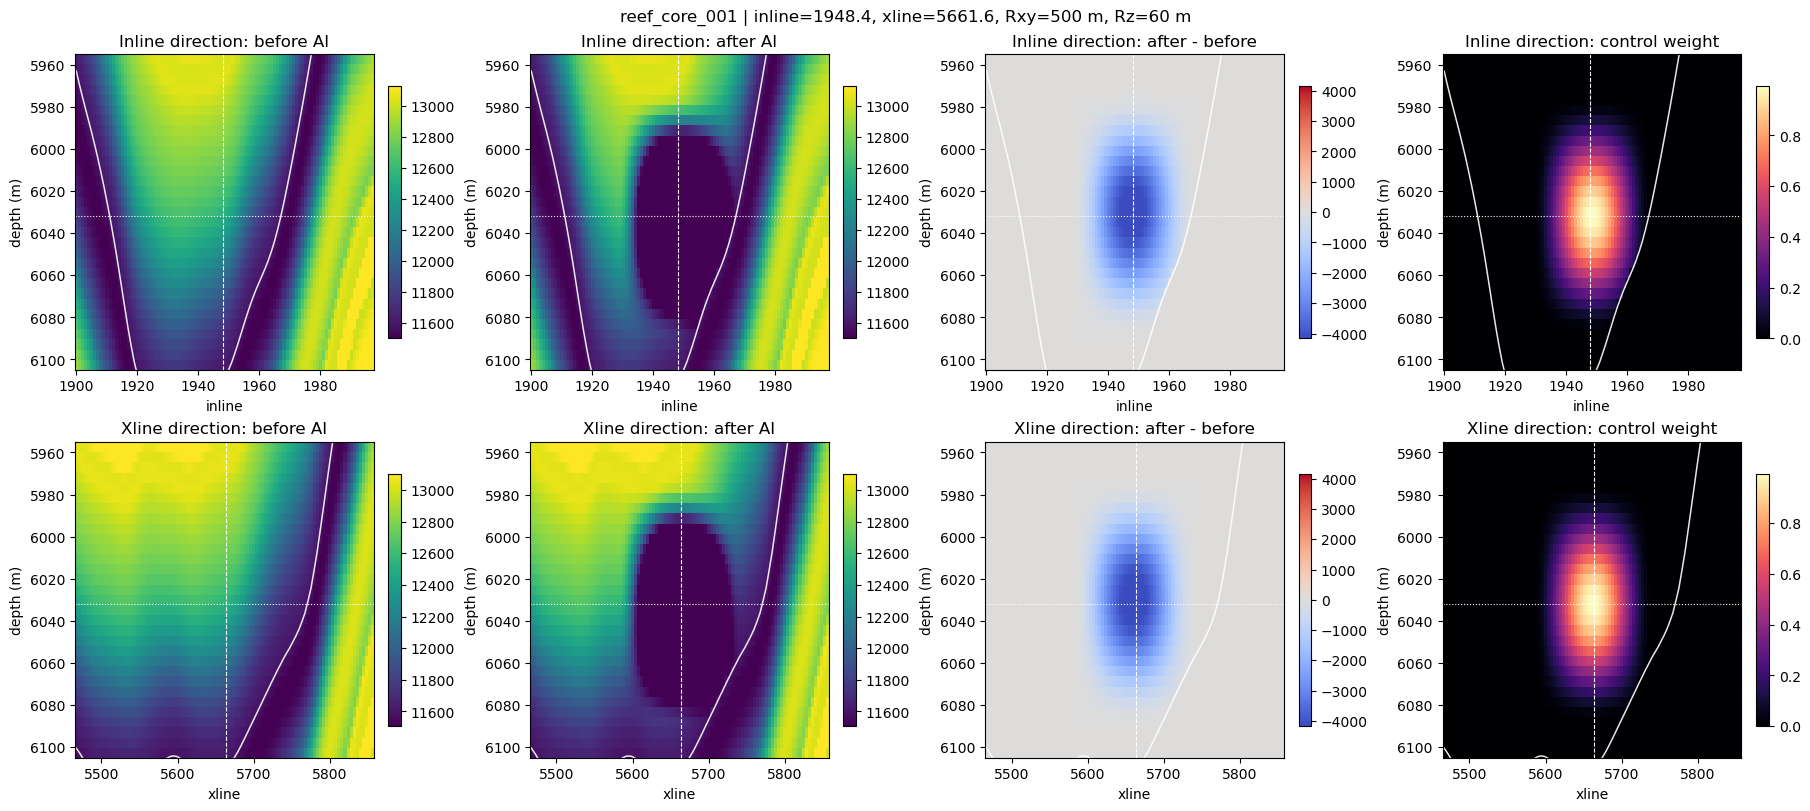

 order          name        x         y  depth_m      inline       xline  zone_top zone_bottom  radius_xy_m  radius_z_m  target_ai  strength  affected_traces  affected_samples  overlap_samples  max_weight  mean_weight  mean_ai_before  mean_ai_after  mean_ai_delta  max_abs_ai_delta
     0 reef_core_001 786093.0 7274335.0   6032.0 1948.429699 5661.640181 horizon_0   horizon_1        500.0        60.0     8000.0       1.0             1262             26975                0    0.995417     0.163581    12315.434441   11517.403876    -798.030565       4540.429466


In [5]:
# Cell 5 - 可反复跑：地质体剖面 QC
# 展示过礁核的 inline/xline 两个方向剖面：before、after、差值、权重。
plot_control_sections(result)

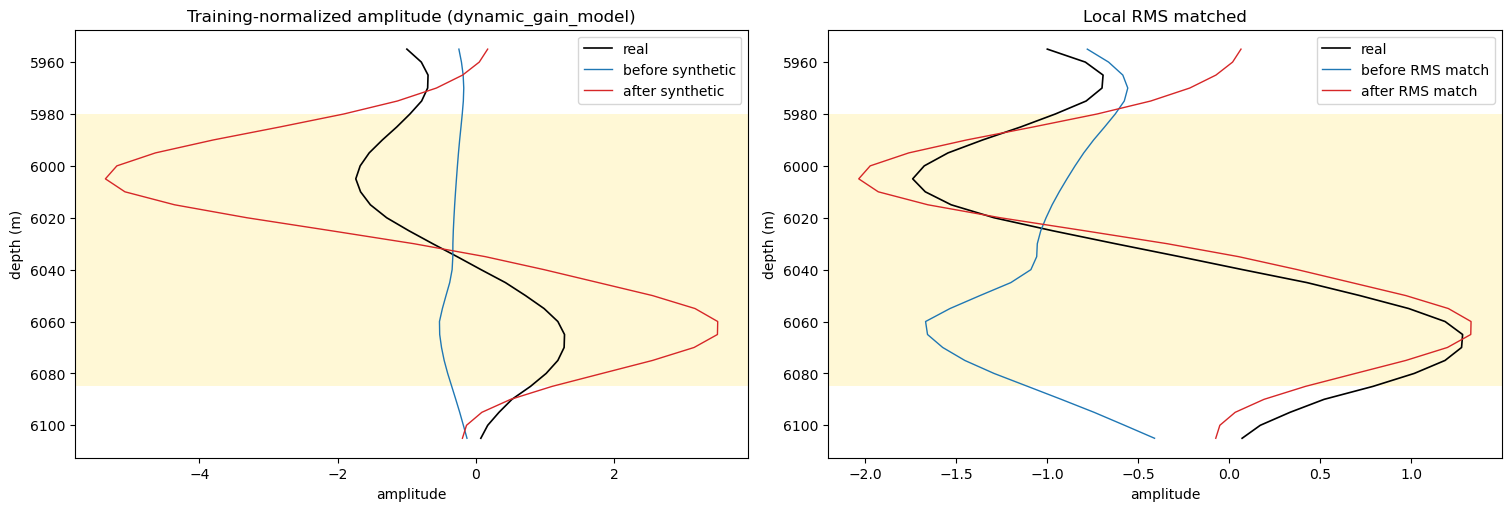

        metric_set         window  n      corr     nmae     rmse  rms_ratio  peak_amp_ratio    scale
train_scale_before display_window 31 -0.660926 1.034954 1.075804   0.316553        0.303671 1.000000
 train_scale_after display_window 31  0.940391 1.543385 1.794734   2.634613        3.083645 1.000000
  rms_match_before display_window 31 -0.660926 1.185500 1.436367   1.000000        0.959305 3.159024
   rms_match_after display_window 31  0.940391 0.309946 0.357409   1.000000        1.170436 0.379562
train_scale_before influence_only 22 -0.880627 1.049242 1.223529   0.314916        0.303671 1.000000
 train_scale_after influence_only 22  0.982108 1.711676 2.101631   2.777905        3.083645 1.000000
  rms_match_before influence_only 22 -0.880627 1.248773 1.652884   1.000000        0.964292 3.175446
   rms_match_after influence_only 22  0.982108 0.175497 0.215492   1.000000        1.110062 0.359984


,metric_set,window,n,corr,nmae,rmse,rms_ratio,peak_amp_ratio,scale
0,train_scale_before,display_window,31,-0.660926,1.034954,1.075804,0.316553,0.303671,1.000000
1,train_scale_after,display_window,31,0.940391,1.543385,1.794734,2.634613,3.083645,1.000000
2,rms_match_before,display_window,31,-0.660926,1.185500,1.436367,1.000000,0.959305,3.159024
3,rms_match_after,display_window,31,0.940391,0.309946,0.357409,1.000000,1.170436,0.379562
4,train_scale_before,influence_only,22,-0.880627,1.049242,1.223529,0.314916,0.303671,1.000000
5,train_scale_after,influence_only,22,0.982108,1.711676,2.101631,2.777905,3.083645,1.000000
6,rms_match_before,influence_only,22,-0.880627,1.248773,1.652884,1.000000,0.964292,3.175446
7,rms_match_after,influence_only,22,0.982108,0.175497,0.215492,1.000000,1.110062,0.359984


In [6]:
# Cell 6 - 可反复跑：礁核道正演 QC
# 同时展示 GINN 训练同口径振幅和局部 RMS 匹配口径；指标会分别给出 display_window 与 influence_only。
metrics, waveforms = forward_qc_at_control_trace(
    ctx,
    result,
    influence_weight_threshold=influence_weight_threshold,
)
plot_forward_qc(metrics, waveforms, gain_mode=ctx.gain_mode)

# 常看指标：corr 越高越好；nmae/rmse 越低越好；rms_ratio 接近 1 表示幅度更接近实际地震。
display(metrics)

In [ ]:
# Cell 7 - 可选反复跑：保存当前 trial，便于比较多组半径
output_csv = trial_csv_path(ctx.repo_root, control_name)
trial_df = append_trial_record(output_csv, result, metrics)
print("Saved trial CSV:", output_csv)

preferred_sort_cols = [
    "influence_only_train_scale_after_corr",
    "display_window_train_scale_after_corr",
    "influence_only_physical_after_corr",  # 兼容旧 trial CSV
    "display_window_physical_after_corr",  # 兼容旧 trial CSV
    "physical_after_corr",  # 兼容旧 trial CSV
]
sort_col = next((col for col in preferred_sort_cols if col in trial_df.columns), None)
if sort_col is not None:
    display(trial_df.sort_values(sort_col, ascending=False).head(20))
else:
    display(trial_df.tail(20))